In [1]:
import subprocess
result = subprocess.run('conda activate prithvi && python -c "import torch; print(torch.__version__)"', 
                       shell=True, capture_output=True, text=True)

# 检查已安装的包
import torch
import sys
from pathlib import Path

print(f'Python: {sys.version[:6]}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA 可用: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "无"}')

# 检查 Clay 相关依赖
packages = ['einops', 'timm', 'huggingface_hub', 'rasterio']
for pkg in packages:
    try:
        __import__(pkg)
        print(f'  ✓ {pkg}')
    except ImportError:
        print(f'  ✗ {pkg} 未安装')

Python: 3.10.2
PyTorch: 2.7.1+cu118
CUDA 可用: True
GPU: NVIDIA GeForce RTX 3090
  ✓ einops


c:\ProgramData\miniconda3\envs\prithvi\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ✓ timm
  ✓ huggingface_hub
  ✓ rasterio


In [3]:
from huggingface_hub import snapshot_download
from pathlib import Path

CLAY_DIR = Path(r'D:\geology AI\hls-foundation-os\pretrained_models\clay')
CLAY_DIR.mkdir(parents=True, exist_ok=True)

print('开始下载 Clay 模型...')
snapshot_download(
    repo_id='made-with-clay/Clay',
    local_dir=str(CLAY_DIR),
    ignore_patterns=['*.msgpack', '*.h5'],
)

print(f'\n下载完成，文件列表:')
for f in sorted(CLAY_DIR.iterdir()):
    size = f.stat().st_size / 1024**2
    print(f'  {f.name}  ({size:.1f} MB)')

开始下载 Clay 模型...


Fetching 4 files: 100%|██████████| 4/4 [12:12<00:00, 183.03s/it]


下载完成，文件列表:
  .cache  (0.0 MB)
  .gitattributes  (0.0 MB)
  config.json  (0.0 MB)
  README.md  (0.0 MB)
  v1.5  (0.0 MB)


In [4]:
from pathlib import Path

CLAY_DIR = Path(r'D:\geology AI\hls-foundation-os\pretrained_models\clay')

print('Clay 目录文件列表:')
for f in sorted(CLAY_DIR.rglob('*')):
    if f.is_file():
        size = f.stat().st_size / 1024**2
        print(f'  {f.relative_to(CLAY_DIR)}  ({size:.1f} MB)')

Clay 目录文件列表:
  .cache\huggingface\.gitignore  (0.0 MB)
  .cache\huggingface\CACHEDIR.TAG  (0.0 MB)
  .cache\huggingface\download\.gitattributes.metadata  (0.0 MB)
  .cache\huggingface\download\config.json.metadata  (0.0 MB)
  .cache\huggingface\download\README.md.metadata  (0.0 MB)
  .cache\huggingface\download\v1.5\clay-v1.5.ckpt.metadata  (0.0 MB)
  .gitattributes  (0.0 MB)
  config.json  (0.0 MB)
  README.md  (0.0 MB)
  v1.5\clay-v1.5.ckpt  (4919.8 MB)


In [5]:
import json

config_path = CLAY_DIR / 'config.json'
with open(config_path) as f:
    cfg = json.load(f)

print('Clay v1.5 配置:')
for k, v in cfg.items():
    print(f'  {k}: {v}')

Clay v1.5 配置:
  _name_or_path: made-with-clay/Clay
  model_type: geovit+DOFA


In [6]:
from pathlib import Path

CLAY_MODEL_DIR = Path(r'D:\geology AI\clay-model')

print('clay-model 目录结构:')
for f in sorted(CLAY_MODEL_DIR.iterdir()):
    print(f'  {f.name}')

clay-model 目录结构:
  .binder
  .git
  .github
  .gitignore
  .pre-commit-config.yaml
  .ruff.toml
  claymodel
  cluster
  CODE_OF_CONDUCT.md
  configs
  copy_data.sh
  docs
  environment.yml
  LICENSE
  pyproject.toml
  README.md
  ruff.toml
  train_clay.sh
  trainer.py
  utils


In [7]:
print('claymodel 目录内容:')
for f in sorted((CLAY_MODEL_DIR / 'claymodel').iterdir()):
    print(f'  {f.name}')

claymodel 目录内容:
  __init__.py
  backbone.py
  callbacks.py
  callbacks_wandb.py
  datamodule.py
  factory.py
  finetune
  model.py
  module.py
  mrl.py
  utils.py


In [9]:
# 查看 model.py 和 factory.py 的内容
import ast

for fname in ['model.py', 'factory.py']:
    fpath = CLAY_MODEL_DIR / 'claymodel' / fname
    print(f'\n=== {fname} 的类和函数 ===')
    with open(fpath) as f:
        tree = ast.parse(f.read())
    for node in ast.walk(tree):
        if isinstance(node, (ast.ClassDef, ast.FunctionDef)):
            print(f'  {node.__class__.__name__}: {node.name}')


=== model.py 的类和函数 ===
  ClassDef: Encoder
  ClassDef: Decoder
  ClassDef: ClayMAE
  FunctionDef: clay_mae_tiny
  FunctionDef: clay_mae_small
  FunctionDef: clay_mae_base
  FunctionDef: clay_mae_large
  FunctionDef: __init__
  FunctionDef: to_patch_embed
  FunctionDef: add_encodings
  FunctionDef: mask_out
  FunctionDef: forward
  FunctionDef: __init__
  FunctionDef: reconstruct_and_add_encoding
  FunctionDef: forward
  FunctionDef: __init__
  FunctionDef: freeze_teacher
  FunctionDef: per_pixel_loss
  FunctionDef: forward

=== factory.py 的类和函数 ===
  ClassDef: FCBlock
  ClassDef: WavesTransformer
  ClassDef: DynamicEmbedding
  FunctionDef: __init__
  FunctionDef: forward
  FunctionDef: __init__
  FunctionDef: forward
  FunctionDef: __init__
  FunctionDef: forward
  FunctionDef: initialize_weights


In [10]:
from claymodel.model import ClayMAE, clay_mae_large
print('✓ ClayMAE 导入成功')

# 查看 clay_mae_large 的参数
import inspect
print('\nclay_mae_large 签名:')
print(inspect.signature(clay_mae_large))

✓ ClayMAE 导入成功

clay_mae_large 签名:
(**kwargs)


In [11]:
import inspect
print(inspect.getsource(clay_mae_large))

def clay_mae_large(**kwargs):
    args = {
        # ENCODER
        "dim": 1024,
        "depth": 24,
        "heads": 16,
        "dim_head": 64,
        "mlp_ratio": 4,
        # DECODER
        "decoder_dim": 512,
        "decoder_depth": 4,
        "decoder_heads": 4,
        "decoder_dim_head": 64,
        "decoder_mlp_ratio": 4,
    }
    args.update(kwargs)
    return ClayMAE(**args)



In [12]:
import torch
from claymodel.model import clay_mae_large

CKPT_PATH = Path(r'D:\geology AI\hls-foundation-os\pretrained_models\clay\v1.5\clay-v1.5.ckpt')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('加载 Clay v1.5 权重...')
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)

print(f'checkpoint 类型: {type(ckpt)}')
if isinstance(ckpt, dict):
    print(f'checkpoint keys: {list(ckpt.keys())}')

加载 Clay v1.5 权重...
checkpoint 类型: <class 'dict'>
checkpoint keys: ['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters']


In [13]:
# 查看 state_dict 的 key 前缀
state_dict = ckpt['state_dict']
print(f'state_dict 共 {len(state_dict)} 个参数')
print('\n前10个 key:')
for k in list(state_dict.keys())[:10]:
    print(f'  {k}')

state_dict 共 675 个参数

前10个 key:
  model.teacher.cls_token
  model.teacher.reg_token
  model.teacher.pos_embed
  model.teacher.patch_embed.proj.weight
  model.teacher.patch_embed.proj.bias
  model.teacher.blocks.0.norm1.weight
  model.teacher.blocks.0.norm1.bias
  model.teacher.blocks.0.attn.qkv.weight
  model.teacher.blocks.0.attn.qkv.bias
  model.teacher.blocks.0.attn.proj.weight


In [14]:
# 去掉 'model.' 前缀，只取 encoder 部分
encoder_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('model.encoder.'):
        new_key = k.replace('model.encoder.', '')
        encoder_state_dict[new_key] = v

print(f'Encoder 参数数量: {len(encoder_state_dict)}')
print('\n前10个 encoder key:')
for k in list(encoder_state_dict.keys())[:10]:
    print(f'  {k}')
    

Encoder 参数数量: 265

前10个 encoder key:
  cls_token
  patch_embedding.weight_generator.weight_tokens
  patch_embedding.weight_generator.bias_token
  patch_embedding.weight_generator.encoder.layers.0.self_attn.in_proj_weight
  patch_embedding.weight_generator.encoder.layers.0.self_attn.in_proj_bias
  patch_embedding.weight_generator.encoder.layers.0.self_attn.out_proj.weight
  patch_embedding.weight_generator.encoder.layers.0.self_attn.out_proj.bias
  patch_embedding.weight_generator.encoder.layers.0.linear1.weight
  patch_embedding.weight_generator.encoder.layers.0.linear1.bias
  patch_embedding.weight_generator.encoder.layers.0.linear2.weight


In [15]:
import inspect
from claymodel.model import Encoder

print(inspect.getsource(Encoder.__init__))

    def __init__(  # noqa: PLR0913
        self,
        mask_ratio,
        patch_size,
        shuffle,
        dim,
        depth,
        heads,
        dim_head,
        mlp_ratio,
    ):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.patch_size = patch_size
        self.shuffle = shuffle
        self.dim = dim
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)

        self.patch_embedding = DynamicEmbedding(
            wave_dim=128,
            num_latent_tokens=128,
            patch_size=patch_size,
            embed_dim=dim,
            is_decoder=False,
        )

        self.transformer = Transformer(
            dim=dim,
            depth=depth,
            heads=heads,
            dim_head=dim_head,
            mlp_dim=int(dim * mlp_ratio),
            fused_attn=True,
        )



In [16]:
from claymodel.model import Encoder

# 用 clay_mae_large 的参数实例化 Encoder
encoder = Encoder(
    mask_ratio=0.0,      # 推理时不 mask
    patch_size=8,
    shuffle=False,
    dim=1024,
    depth=24,
    heads=16,
    dim_head=64,
    mlp_ratio=4,
)

# 加载权重
msg = encoder.load_state_dict(encoder_state_dict, strict=False)
print(f'missing:    {len(msg.missing_keys)}')
print(f'unexpected: {len(msg.unexpected_keys)}')

encoder = encoder.to(DEVICE).eval()
total_p = sum(p.numel() for p in encoder.parameters())
print(f'\n✓ Clay Encoder 加载成功  参数量: {total_p/1e6:.1f}M')

missing:    0
unexpected: 0

✓ Clay Encoder 加载成功  参数量: 311.4M


In [17]:
import inspect
# 只打印 forward 的签名和前20行
src = inspect.getsource(Encoder.forward)
lines = src.split('\n')
for line in lines[:25]:
    print(line)

    def forward(self, datacube):
        cube, time, latlon, gsd, waves = (
            datacube["pixels"],  # [B C H W]
            datacube["time"],  # [B 2]
            datacube["latlon"],  # [B 2]
            datacube["gsd"],  # 1
            datacube["waves"],  # [N]
        )  # [B C H W]

        B, C, H, W = cube.shape

        patches, waves_encoded = self.to_patch_embed(
            cube, waves
        )  # [B L D] - patchify & create embeddings per patch
        # TODO: Add time & latlon as encoding to patches
        patches = self.add_encodings(
            patches,
            time,
            latlon,
            gsd,
        )  # [B L D] - add position encoding to the embeddings

        # mask out patches
        (
            unmasked_patches,


In [18]:
import numpy as np
import rasterio
import torch
from pathlib import Path

# 读取 Week 1 的悉尼 HLS 数据
DATA_DIR = Path(r'D:\geology AI\data\raw\hls_sample')
BANDS = ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12']

# 读取并裁剪中心 224×224
arrays = []
for band in BANDS:
    with rasterio.open(DATA_DIR / f'{band}.tif') as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = 0.0
    H, W = arr.shape
    cy, cx = H//2, W//2
    arr = arr[cy-112:cy+112, cx-112:cx+112]
    arrays.append(arr)

img = np.stack(arrays, axis=0)  # (6, 224, 224)
print(f'影像形状: {img.shape}')

# Clay 的波长定义（单位：微米）
# B02=0.49, B03=0.56, B04=0.665, B8A=0.865, B11=1.61, B12=2.19
waves = torch.tensor([0.49, 0.56, 0.665, 0.865, 1.61, 2.19], dtype=torch.float32)

# 构建 datacube
pixels = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # (1,6,224,224)

# 归一化到 0~1（Clay 期望）
for i in range(6):
    p2, p98 = np.percentile(img[i], [2, 98])
    pixels[0, i] = torch.clamp((pixels[0, i] - p2) / (p98 - p2 + 1e-8), 0, 1)

datacube = {
    'pixels':  pixels.to(DEVICE),                                    # (1,6,224,224)
    'time':    torch.zeros(1, 2).to(DEVICE),                         # (1,2) year, day
    'latlon':  torch.tensor([[-33.87, 151.21]]).to(DEVICE),          # 悉尼坐标
    'gsd':     torch.tensor(30.0).to(DEVICE),                        # 30m 分辨率
    'waves':   waves.to(DEVICE),                                      # (6,)
}

print('datacube 构建完成:')
for k, v in datacube.items():
    if hasattr(v, 'shape'):
        print(f'  {k}: {v.shape}')
    else:
        print(f'  {k}: {v}')

影像形状: (6, 224, 224)
datacube 构建完成:
  pixels: torch.Size([1, 6, 224, 224])
  time: torch.Size([1, 2])
  latlon: torch.Size([1, 2])
  gsd: torch.Size([])
  waves: torch.Size([6])


In [22]:
datacube = {
    'pixels':  pixels.to(DEVICE),
    'time':    torch.zeros(1, 4).to(DEVICE),     # ← 改为 4 维
    'latlon':  torch.tensor([[-33.87, 151.21, -33.87, 151.21]]).to(DEVICE),  # ← 改为 4 维
    'gsd':     torch.tensor(30.0).to(DEVICE),
    'waves':   waves.to(DEVICE),
}

print('datacube 重建:')
for k, v in datacube.items():
    if hasattr(v, 'shape'):
        print(f'  {k}: {v.shape}')

with torch.no_grad():
    try:
        output = encoder(datacube)
        print(f'\n输出类型: {type(output)}')
        if isinstance(output, (list, tuple)):
            for i, o in enumerate(output):
                if hasattr(o, 'shape'):
                    print(f'  [{i}] shape: {o.shape}')
        elif hasattr(output, 'shape'):
            print(f'输出 shape: {output.shape}')
    except Exception as e:
        print(f'错误: {e}')

datacube 重建:
  pixels: torch.Size([1, 6, 256, 256])
  time: torch.Size([1, 4])
  latlon: torch.Size([1, 4])
  gsd: torch.Size([])
  waves: torch.Size([6])

输出类型: <class 'tuple'>
  [0] shape: torch.Size([1, 1025, 1024])
  [1] shape: torch.Size([1, 1024])
  [2] shape: torch.Size([1, 0])
  [3] shape: torch.Size([1, 1024])


In [25]:
# unmasked_patches: (1, 1025, 1024)
# 第 0 个位置是 CLS token 的真实 embedding
cls_embedding = unmasked_patches[0, 0, :].cpu().numpy()    # (1024,)
patch_embeddings = unmasked_patches[0, 1:, :].cpu().numpy() # (1024, 1024)

print(f'CLS embedding 形状:    {cls_embedding.shape}')
print(f'CLS embedding 范围:    [{cls_embedding.min():.3f}, {cls_embedding.max():.3f}]')
print(f'CLS embedding 均值:    {cls_embedding.mean():.3f}  std={cls_embedding.std():.3f}')
print(f'\npatch embeddings 形状: {patch_embeddings.shape}')
print(f'patch embeddings 范围: [{patch_embeddings.min():.3f}, {patch_embeddings.max():.3f}]')
print('\n✓ Clay Embedding 提取成功')

CLS embedding 形状:    (1024,)
CLS embedding 范围:    [-1.319, 0.550]
CLS embedding 均值:    0.000  std=0.092

patch embeddings 形状: (1024, 1024)
patch embeddings 范围: [-1.320, 0.999]

✓ Clay Embedding 提取成功


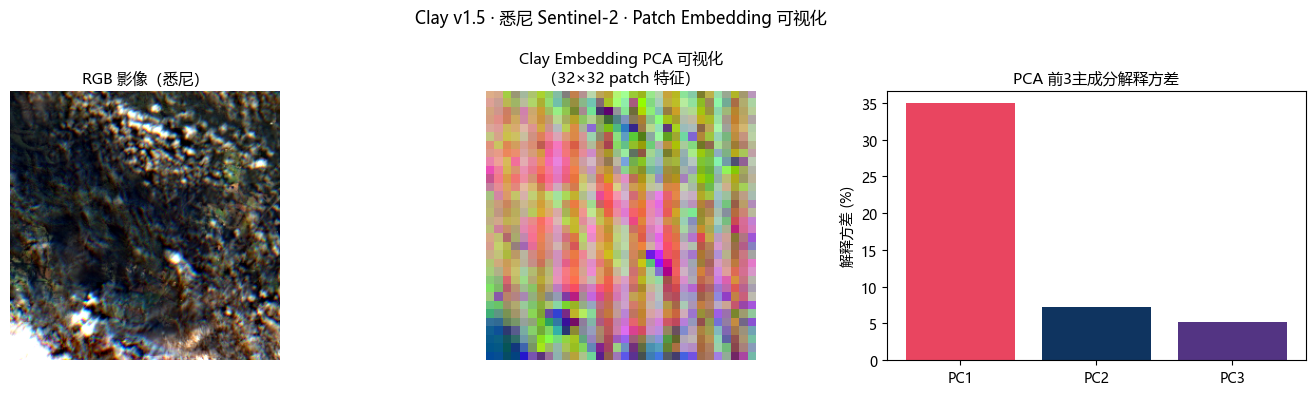

图已保存


In [26]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('font', family='Microsoft YaHei')
matplotlib.rcParams['axes.unicode_minus'] = False
import numpy as np
from sklearn.decomposition import PCA

# patch embeddings: (1024, 1024) → reshape 为 32×32 空间
# 256×256 图像，patch_size=8 → 32×32 = 1024 个 patch
grid_size = 32

# PCA 降到 3 维用于可视化
pca = PCA(n_components=3)
feat_pca = pca.fit_transform(patch_embeddings)  # (1024, 3)
feat_pca = feat_pca.reshape(grid_size, grid_size, 3)

# 归一化到 0~1
for i in range(3):
    mn, mx = feat_pca[:,:,i].min(), feat_pca[:,:,i].max()
    feat_pca[:,:,i] = (feat_pca[:,:,i] - mn) / (mx - mn + 1e-8)

# RGB 影像（用于对比）
def make_rgb(img, p_low=2, p_high=98):
    rgb = img[[2,1,0]].copy()
    for i in range(3):
        lo, hi = np.percentile(rgb[i], [p_low, p_high])
        rgb[i] = np.clip((rgb[i]-lo)/(hi-lo+1e-8), 0, 1)
    return rgb.transpose(1,2,0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(make_rgb(img))
axes[0].set_title('RGB 影像（悉尼）', fontsize=11)
axes[0].axis('off')

axes[1].imshow(feat_pca)
axes[1].set_title('Clay Embedding PCA 可视化\n（32×32 patch 特征）', fontsize=11)
axes[1].axis('off')

axes[2].bar(range(3), pca.explained_variance_ratio_*100,
            color=['#e94560','#0f3460','#533483'])
axes[2].set_xticks(range(3))
axes[2].set_xticklabels(['PC1','PC2','PC3'])
axes[2].set_ylabel('解释方差 (%)')
axes[2].set_title('PCA 前3主成分解释方差', fontsize=11)

plt.suptitle('Clay v1.5 · 悉尼 Sentinel-2 · Patch Embedding 可视化', fontsize=12)
plt.tight_layout()

FIG_DIR = Path(r'D:\geology AI\results\figures')
plt.savefig(FIG_DIR / 'week3_10_clay_embedding.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存')

In [27]:
import subprocess, os
from pathlib import Path

REPO_DIR = r'D:\geology AI'
os.chdir(REPO_DIR)

def git(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=REPO_DIR)
    out = (r.stdout + r.stderr).strip()
    if out: print(out)

git('git add notebooks/10_clay_embedding.ipynb')
git('git add results/figures/week3_10_clay_embedding.png')
git('git commit -m "Week3 Day1: Clay v1.5 encoder loaded + patch embedding extracted (1024-dim)"')
git('git push origin main')
print('\n✓ Day 1 已推送到 GitHub')

[main d9d5381] Week3 Day1: Clay v1.5 encoder loaded + patch embedding extracted (1024-dim)
 2 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 notebooks/10_clay_embedding.ipynb
 create mode 100644 results/figures/week3_10_clay_embedding.png
To https://github.com/lofophil/geo-foundation-experiments.git
   c1236de..d9d5381  main -> main

✓ Day 1 已推送到 GitHub
